Задания не обязательно решать в том порядке, в котором они приводятся.

Обязательных баллов 4

# Задание 1. *Сумма деревьев (0.5 балла)

## Построим график аппроксимируемой функции

In [3]:
from sklearn.tree import DecisionTreeRegressor

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # для 3d-визуализации в matplotlib
from matplotlib import cm

In [5]:
h = .02 # grid size

x1_min, x1_max = -2.5, 2.5
x2_min, x2_max = -2.5, 2.5
x1, x2 = np.meshgrid(np.arange(x1_min, x1_max, h),
                         np.arange(x2_min, x2_max, h))

y = np.cos(x1) ** 2 + np.sin(x2) ** 2


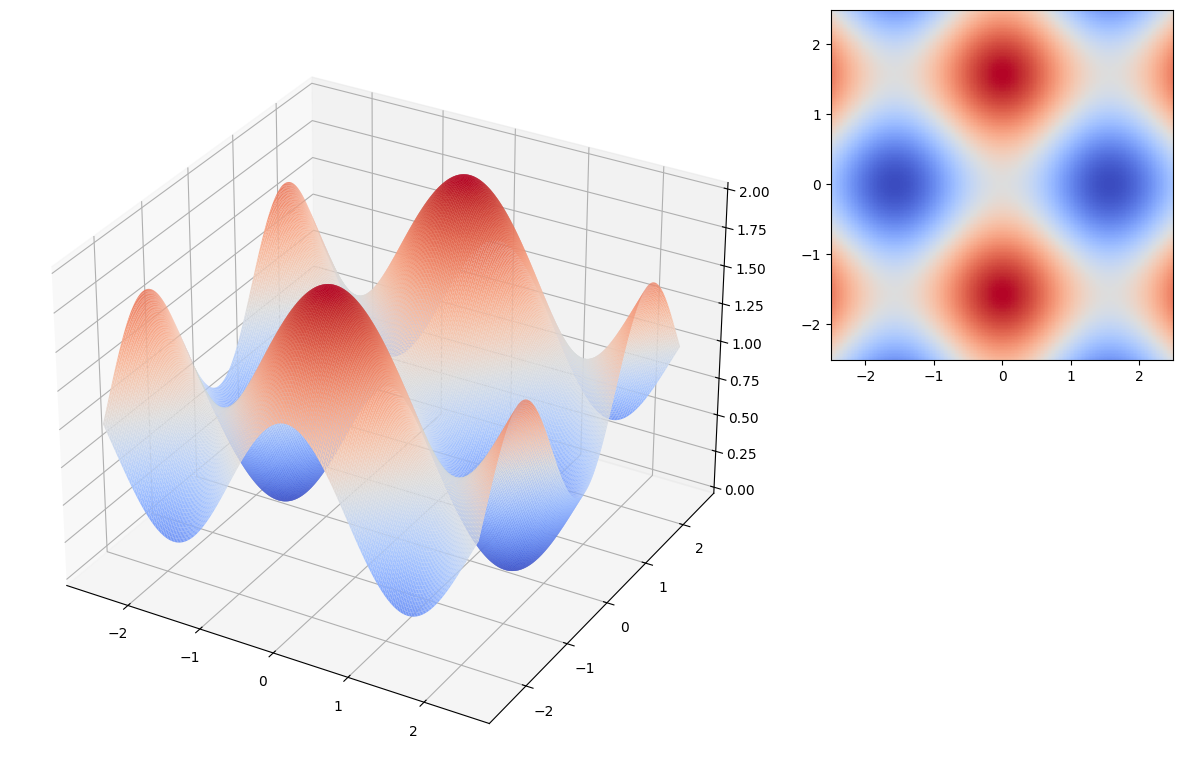

In [6]:

plt.figure(figsize=(15,10))
# https://towardsdatascience.com/subplots-in-matplotlib-a-guide-and-tool-for-planning-your-plots-7d63fa632857
ax = plt.subplot2grid((2, 3), (0, 0), rowspan=2, colspan=2, projection='3d')

ax.plot_surface(x1, x2, y, cmap=cm.coolwarm, linewidth=0, rstride=1, cstride=1)

ax = plt.subplot2grid((2, 3), (0, 2), rowspan=1, colspan=1)
ax.pcolormesh(x1, x2, y, cmap=cm.coolwarm, )
plt.show()

## Получим выборку

In [7]:
sample_size = 500

x1_sample = np.random.uniform(x1_min, x1_max, sample_size)
x2_sample = np.random.uniform(x2_min, x2_max, sample_size)

noise = np.random.normal(0, 0.2, sample_size)
y_sample = np.cos(x1_sample) ** 2 + np.sin(x2_sample) ** 2 + noise

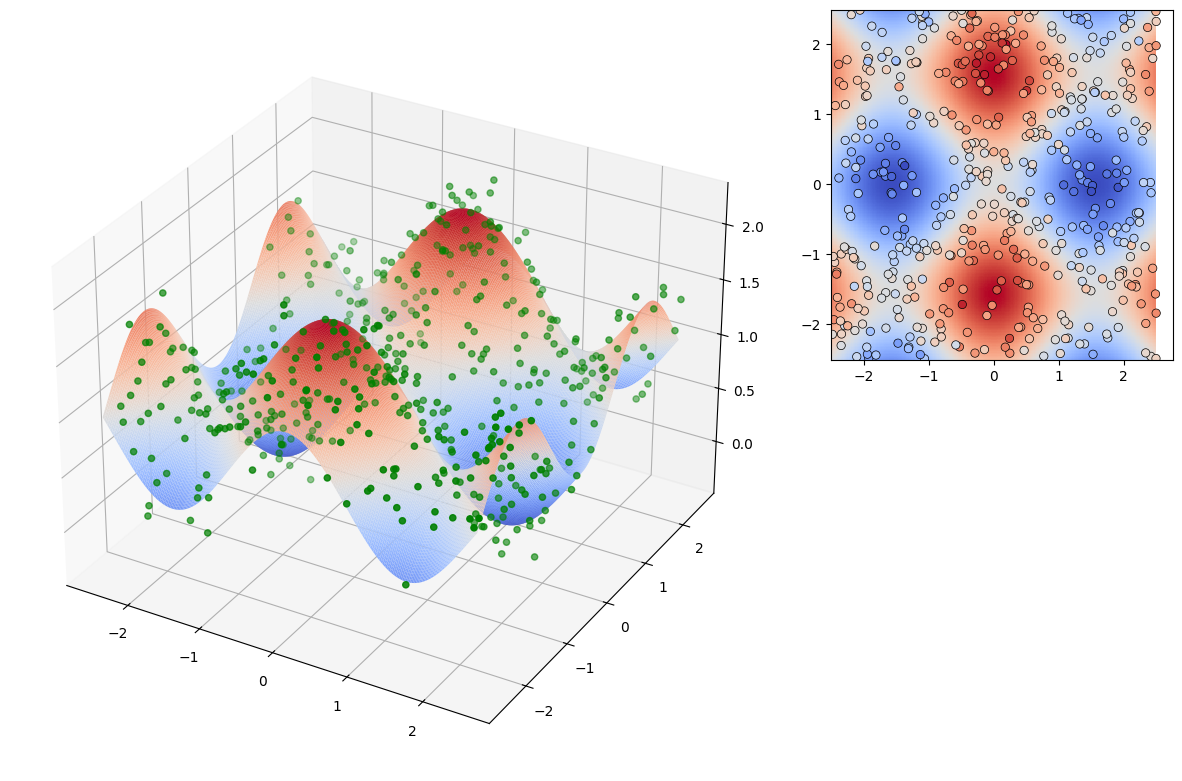

In [8]:
plt.figure(figsize=(15,10))

ax = plt.subplot2grid((2, 3), (0, 0), rowspan=2, colspan=2, projection='3d')

ax.plot_surface(x1, x2, y, cmap=cm.coolwarm, linewidth=1, rstride=1, cstride=1)
ax.scatter3D(x1_sample, x2_sample, y_sample, color='g')


ax = plt.subplot2grid((2, 3), (0, 2), rowspan=1, colspan=1)

ax.pcolormesh(x1, x2, y, cmap=cm.coolwarm)
ax.scatter(x1_sample, x2_sample, c=y_sample, cmap=cm.coolwarm, edgecolor='black', linewidth=0.5)
plt.show()


## Обучим два дерева

In [9]:
X_sample = np.stack([x1_sample, x2_sample], axis=1)

In [10]:
tree1 = DecisionTreeRegressor(max_depth=2)
tree1.fit(X_sample, y_sample)

DecisionTreeRegressor(max_depth=2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


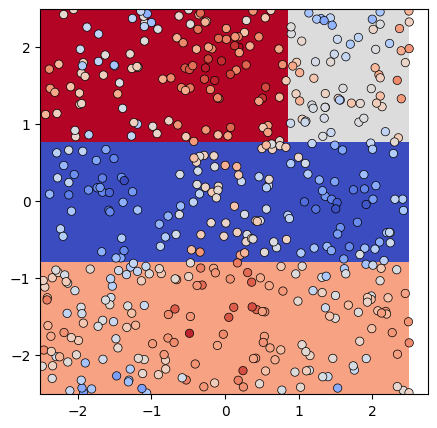

In [11]:
X = pd.DataFrame(np.stack([np.ravel(x1), np.ravel(x2)], axis=1), columns=['x1', 'x2'])
y_predicted = tree1.predict(X)
y_predicted = y_predicted.reshape(x1.shape[0], x1.shape[1])

# Построим, как это выглядит в двумерном представлении
plt.figure(figsize=(5,5))


plt.pcolormesh(x1, x2, y_predicted, cmap=cm.coolwarm)
plt.scatter(x1_sample, x2_sample, c=y_sample, cmap=cm.coolwarm, edgecolor='black',
           linewidth=0.5)
plt.show()

In [12]:
y_error = y_sample - tree1.predict(X_sample)
tree2 = DecisionTreeRegressor(max_depth=2)
tree2.fit(X_sample, y_error)

DecisionTreeRegressor(max_depth=2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


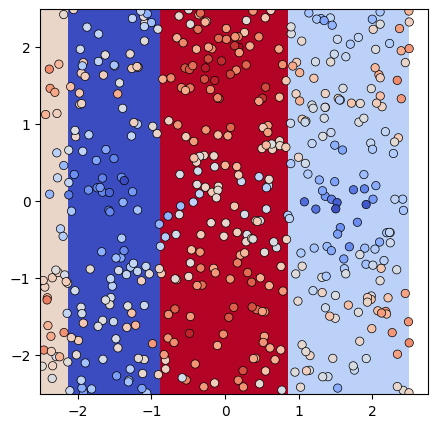

In [13]:
X = pd.DataFrame(np.stack([np.ravel(x1), np.ravel(x2)], axis=1), columns=['x1', 'x2'])
y_predicted2 = tree2.predict(X)
y_predicted2 = y_predicted2.reshape(x1.shape[0], x1.shape[1])

# Построим, как это выглядит
plt.figure(figsize=(5,5))


plt.pcolormesh(x1, x2, y_predicted2, cmap=cm.coolwarm)
plt.scatter(x1_sample, x2_sample, c=y_sample, cmap=cm.coolwarm, edgecolor='black',
           linewidth=0.5)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


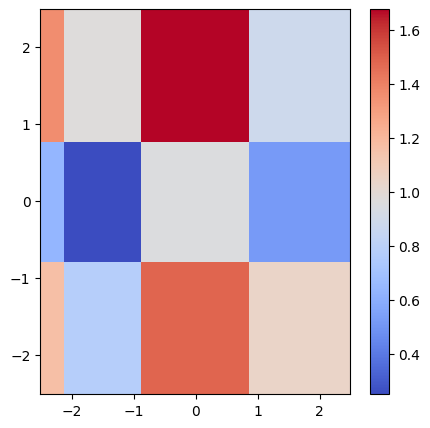

In [14]:
X = pd.DataFrame(np.stack([np.ravel(x1), np.ravel(x2)], axis=1), columns=['x1', 'x2'])
y_predicted2 = tree2.predict(X)
y_predicted2 = y_predicted2.reshape(x1.shape[0], x1.shape[1])

# Построим, как это выглядит
plt.figure(figsize=(5,5))


plt.pcolormesh(x1, x2, y_predicted + y_predicted2, cmap=cm.coolwarm)
plt.colorbar()
plt.show()

In [15]:
np.unique(y_predicted + y_predicted2)

array([0.25146377, 0.52259668, 0.64034031, 0.77506652, 0.88160866,
       0.95714467, 0.9692997 , 1.04619943, 1.16394306, 1.35817623,
       1.48074742, 1.67498059])

## Получение одного дерева

При помощи кода из лекции задайте дерево решений, которое **примерно** воспроизводит границы решений, полученные выше сложением двух деревьев

Такое дерево не единственное, вы можете продемонстрировать любое, удолетворяющее условию

In [16]:
from dataclasses import dataclass
from typing import Union, List

@dataclass(unsafe_hash=True)
class RegressionLeaf:
    value: float

@dataclass(unsafe_hash=True)
class RegressionInnerNode:
    feature: str # feature name if not leaf
    th: float # threshold for the feature
    left: Union['InnerNode', RegressionLeaf]
    right: Union['InnerNode', RegressionLeaf]


def variance_decrease(y, mask):
    d_l = y[mask].var()
    d_r = y[~mask].var()
    d_node = y.var()

    N = y.shape[0]
    N_l = mask.sum()
    N_r = N - N_l
    decrease = d_node - N_l/N * d_l - N_r / N * d_r
    return decrease

def naive_threshold_candidates(feature):
    uniq_vals = np.unique(feature) # already returned sorted
    th = (uniq_vals[:-1] + uniq_vals[1:]) / 2
    return th

def find_best_split(df, features, target_col, quality_measure):
    best_decrease = -1
    best_split = (None, None)
    for f in features:
        for th in naive_threshold_candidates(df[f]):
            mask = df[f] <= th
            y = df[target_col]

            decrease = quality_measure(y, mask)

            if decrease > best_decrease:
                best_decrease = decrease
                best_split = (f, th)
    return best_split


def construct_regression_node(df, features, target_col, quality_measure, max_depth=2, eps=0.00001):
    y = df[target_col]
    var  =y.var()
    if var < eps or max_depth == 0: # only one class or max depth exceeded
        label = y.mean()
        return RegressionLeaf(label)
    #else
    best_split = find_best_split(df, features, target_col, quality_measure)
    if best_split[0] is None: # no split exists:
        label = y.mean()
        return RegressionLeaf(label)

    f, th = best_split
    mask = df[f] <= th
    left_df = df[mask]
    right_df = df[~mask]

    left_node = construct_regression_node(left_df, features, target_col, quality_measure, max_depth=max_depth-1)
    right_node = construct_regression_node(right_df, features, target_col, quality_measure, max_depth=max_depth-1)

    node = RegressionInnerNode(feature=f,
                     th=th,
                     left=left_node,
                     right=right_node)
    return node


@dataclass(unsafe_hash=True)
class RegressionDecisionTree:
    root: Union[RegressionInnerNode, RegressionLeaf]

    def predict(self, x) -> str:
        curnode = self.root
        while not isinstance(curnode, RegressionLeaf):
            if x[curnode.feature] > curnode.th:
                curnode = curnode.right
            else:
                curnode = curnode.left
        return curnode.value

    @classmethod
    def make(cls, df: pd.DataFrame, features: List[str], target_col: str, quality_measure=variance_decrease, max_depth: int=2):
        node = construct_regression_node(df, features=features, target_col=target_col, quality_measure=quality_measure, max_depth=max_depth, eps=0.00001)
        return cls(node)

In [17]:
np.unique(y_predicted + y_predicted2) # 0.28963385,

array([0.25146377, 0.52259668, 0.64034031, 0.77506652, 0.88160866,
       0.95714467, 0.9692997 , 1.04619943, 1.16394306, 1.35817623,
       1.48074742, 1.67498059])

In [18]:
data = pd.DataFrame(X_sample, columns=['x1', 'x2'])
data['target'] = y_sample

In [19]:
# Example, modify
custom_tree = RegressionDecisionTree(root=RegressionInnerNode(feature='x2',
                                                th=-0.8,
                                                left=RegressionInnerNode(
                                                    feature='x1',
                                                    th=-0.8,
                                                    left=RegressionLeaf(value=1.04323424),
                                                    right=RegressionLeaf(1.56142122)),
                                                right=RegressionLeaf(0.40992183)))

In [20]:
np.unique(y_predicted + y_predicted2)

array([0.25146377, 0.52259668, 0.64034031, 0.77506652, 0.88160866,
       0.95714467, 0.9692997 , 1.04619943, 1.16394306, 1.35817623,
       1.48074742, 1.67498059])

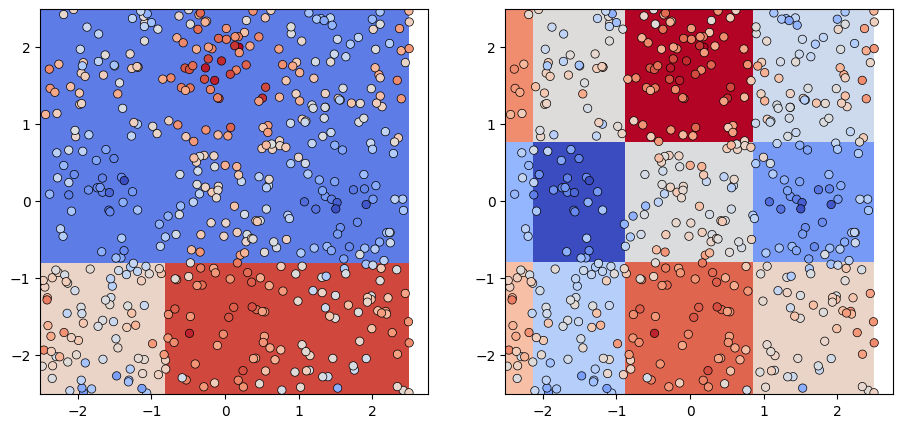

In [21]:
X = pd.DataFrame(np.stack([np.ravel(x1), np.ravel(x2)], axis=1), columns=['x1', 'x2'])
y_approx = np.array([custom_tree.predict(x) for _, x in X.iterrows()])
y_approx = y_approx.reshape(x1.shape[0], x1.shape[1])

# Построим, как это выглядит
vmin, vmax = (y_predicted + y_predicted2).min(), (y_predicted + y_predicted2).max()
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(11,5))
ax1.pcolormesh(x1, x2, y_approx, cmap=cm.coolwarm, vmin=vmin, vmax=vmax)
ax1.scatter(x1_sample, x2_sample, c=y_sample, cmap=cm.coolwarm, edgecolor='black',
           linewidth=0.5)
ax2.pcolormesh(x1, x2, y_predicted + y_predicted2, cmap=cm.coolwarm)
ax2.scatter(x1_sample, x2_sample, c=y_sample, cmap=cm.coolwarm, edgecolor='black',
           linewidth=0.5)
plt.show()

# Задание 2. Имплементируем бустинг для случае регрессии (0.5 балла)

## Получение выборки

In [22]:
def get_func_sample(sample_size = 500):

    x1_sample = np.random.uniform(x1_min, x1_max, sample_size)
    x2_sample = np.random.uniform(x2_min, x2_max, sample_size)

    noise = np.random.normal(0, 0.2, sample_size)
    y = np.cos(x1_sample) ** 2 + np.sin(x2_sample) ** 2 + noise
    X = pd.DataFrame(np.stack([x1_sample, x2_sample], axis=1))

    return X, y

In [23]:
import numpy as np
X_train, y_train = get_func_sample(sample_size=500)
X_val, y_val = get_func_sample(sample_size=500)

## Реализация градиентного бустинга

In [24]:
from sklearn.metrics import mean_squared_error

class TrivialRegressorPredictor:
    def __init__(self, value):
        self.value = value

    def predict(self, X):
        return np.full(( X.shape[0], ), fill_value=self.value)

class TrivialBoostingRegressor:
    def __init__(self, n_iters=100, max_depth=3, learning_rate=0.1):
        self.trivial_predictor = None
        self.ensemble = None
        self.n_iters = n_iters
        self.max_depth = max_depth
        self.learning_rate = learning_rate

    def predict(self, X):
        y_pred = self.trivial_predictor.predict(X)
        for base_model in self.ensemble:
            y_pred += self.learning_rate * base_model.predict(X)
        return y_pred

    def fit(self, X, y, X_val=None, y_val=None):
        self.ensemble = []
        self.trivial_predictor = TrivialRegressorPredictor(value=y.mean())
        train_losses = []
        val_losses = []
        for _ in range(self.n_iters):
            y_pred = self.predict(X)
            train_losses.append(mean_squared_error(y, y_pred))
            if X_val is not None and y_val is not None:
                y_val_pred = self.predict(X_val)
                val_losses.append(mean_squared_error(y_val, y_val_pred))
            antigrad = y - y_pred
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X=X, y=antigrad)
            self.ensemble.append(tree)

        y_pred = self.predict(X)
        train_losses.append(mean_squared_error(y, y_pred))
        if X_val is not None and y_val is not None:
            y_val_pred = self.predict(X_val)
            val_losses.append(mean_squared_error(y_val, y_val_pred))
        return train_losses[1:], val_losses[1:] # remove trivial prediction



Подберите оптимальный learning rate. Объясните ваш выбор

Final validation loss is 0.04544516258595213


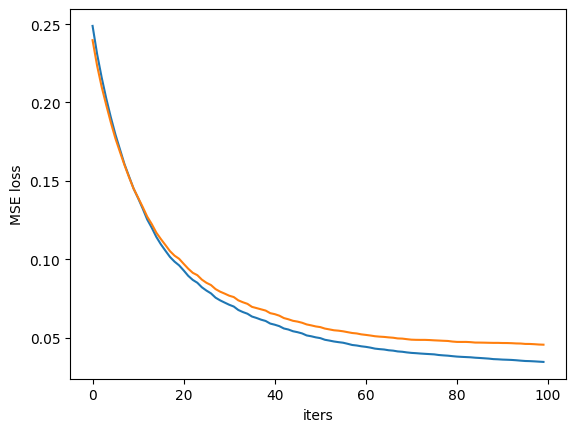

In [25]:
boosting = TrivialBoostingRegressor(n_iters=100, max_depth=2, learning_rate=0.1)
train_losses, val_losses = boosting.fit(X_train, y_train, X_val, y_val)
plt.plot(train_losses)
plt.plot(val_losses)
plt.xlabel('iters')
plt.ylabel('MSE loss')
print(f'Final validation loss is {val_losses[-1]}')

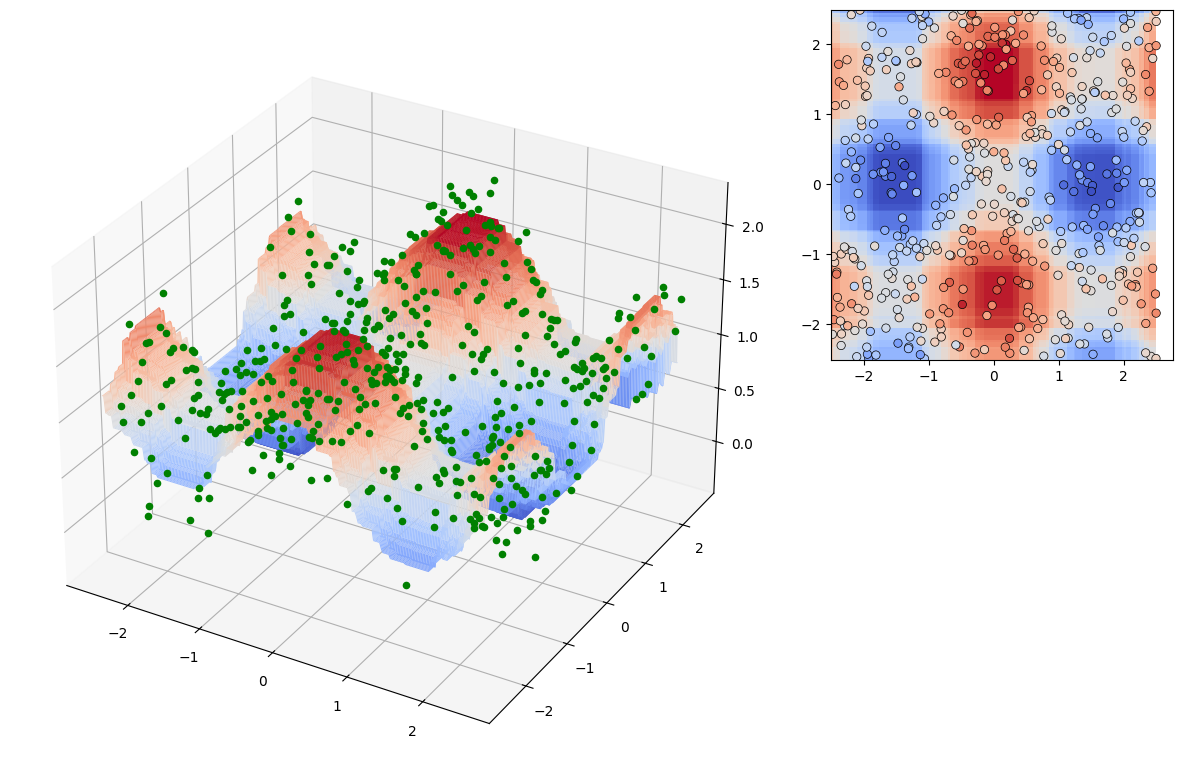

In [26]:
X = pd.DataFrame(np.stack([np.ravel(x1), np.ravel(x2)], axis=1))
y_predicted = boosting.predict(X)

y_predicted = y_predicted.reshape(x1.shape[0], x1.shape[1])
# Построим, как это выглядит
plt.figure(figsize=(15,10))

ax = plt.subplot2grid((2, 3), (0, 0), rowspan=2, colspan=2, projection='3d')

ax.plot_surface(x1, x2, y_predicted, cmap=cm.coolwarm, linewidth=1, rstride=1, cstride=1)
ax.scatter3D(x1_sample, x2_sample, y_sample, color='g', depthshade=False)

ax = plt.subplot2grid((2, 3), (0, 2), rowspan=1, colspan=1)

ax.pcolormesh(x1, x2, y_predicted, cmap=cm.coolwarm)
ax.scatter(x1_sample, x2_sample, c=y_sample, cmap=cm.coolwarm, edgecolor='black',
           linewidth=0.5)
plt.show()

In [27]:
from sklearn.ensemble import GradientBoostingRegressor

In [28]:
def get_losses(sklearn_boost, X, y):
    losses = []
    for pred in sklearn_boost.staged_predict(X):
        losses.append(mean_squared_error(y, pred))
    return losses

Final validation loss is 0.04544516258595214


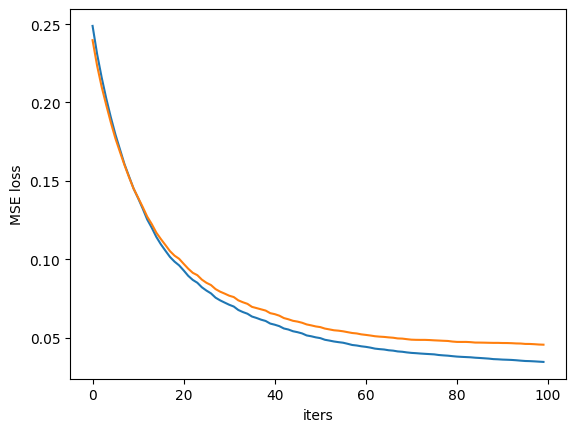

In [29]:
boosting = GradientBoostingRegressor(n_estimators=100,
                                     max_depth=2,
                                     learning_rate=0.1,
                                     criterion='squared_error')
boosting.fit(X_train, y_train)
train_losses = get_losses(boosting, X_train, y_train)
val_losses = get_losses(boosting, X_val, y_val)

plt.plot(train_losses)
plt.plot(val_losses)
plt.xlabel('iters')
plt.ylabel('MSE loss')
print(f'Final validation loss is {val_losses[-1]}')

# Задание 3 (1 балл) Коэффициент b в случае MSE

Покажите, почему в данном случае наша простейшая реализация совпадает по поведению с реализацией sklearn

Конкретно - в нашем случае мы не реализовали regression in the leaves и не заменяли значения, предсказываемые изначальным деревом на $b_i$.




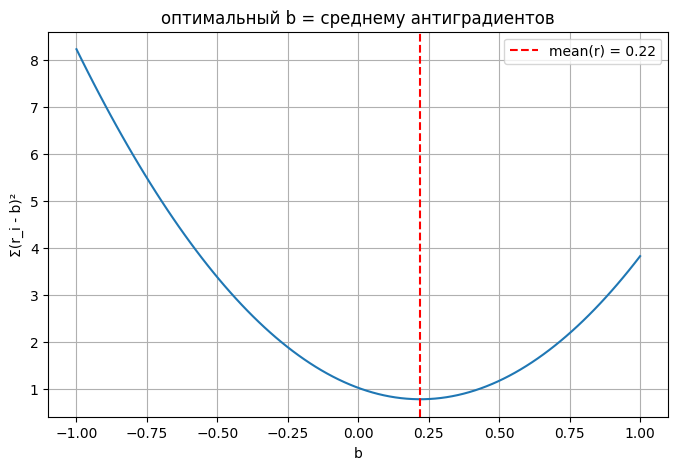

Оптимальный b: 0.22000000000000003


In [30]:
import numpy as np
import matplotlib.pyplot as plt

r = np.array([0.5, -0.3, 0.8, -0.1, 0.2])  # антиградиенты

b_optimal = r.mean()  # = 0.22

b_range = np.linspace(-1, 1, 100)
losses = [np.sum((r - b)**2) for b in b_range]

plt.figure(figsize=(8, 5))
plt.plot(b_range, losses)
plt.axvline(b_optimal, color='r', linestyle='--', label=f'mean(r) = {b_optimal:.2f}')
plt.xlabel('b')
plt.ylabel('Σ(r_i - b)²')
plt.title('оптимальный b = среднему антиградиентов')
plt.legend()
plt.grid(True)
plt.show()
print(f"Оптимальный b: {b_optimal}")

Если взять b меньше 0.22 - ошибка большe, если взять b меньше - ошибка больше тоже, ровно b - ошибка минимльна
Дерево, обученное предсказывать антиградиенты, выдаст b=mean в каждом листе, это и есть оптимальное значение для минимищации MSE
В бустинге мы считаем осттаки как = реал знач - текущ предсказание, далее обучаем деерво предсказывать эти остатки, далее добавляем предсказания дерева к модели
Для MSE дерево, обученное на антиградиентах, автоматически даёт оптимальное значение в листьях, тк задача линейная.
То есть для MSE наша простая реализация бустинга (без  оптимизации листьев) эквивалентна реализации sklearn.

# Задание 4 (1 балл) Бустинг для задачи классификации

## Получим выборку для работы

In [31]:
from sklearn.datasets import make_moons

In [32]:
X_train, y_train = make_moons(n_samples=500, noise=0.15)
X_val, y_val = make_moons(n_samples=500, noise=0.15)

#plt.scatter(X_train[:, 0], X_train[:, 1], c=y)

## Наивная реализация градиентного бустинга

In [33]:
from sklearn.metrics import log_loss
from scipy.special import expit as sigmoid
class TrivialClassifierPredictor:
    def __init__(self, p):
        self.value = np.log(p / (1-p))
    def predict(self, X):
        return np.full(( X.shape[0], ), fill_value=self.value)

class TrivialBoostingClassifier:
    def __init__(self, n_iters=100, max_depth=3, learning_rate=0.1):
        self.trivial_predictor = None
        self.ensemble = None
        self.n_iters = n_iters
        self.max_depth = max_depth
        self.learning_rate = learning_rate

    def predict(self, X):
        y_pred = self.trivial_predictor.predict(X)
        for base_model in self.ensemble:
            y_pred += self.learning_rate * base_model.predict(X)
        return sigmoid(y_pred)

    def fit(self, X, y, X_val=None, y_val=None):
        self.ensemble = []
        self.trivial_predictor = TrivialClassifierPredictor(p=y.mean())
        train_losses = []
        val_losses = []
        for _ in range(self.n_iters):
            y_pred = self.predict(X)
            train_losses.append(log_loss(y, y_pred))
            if X_val is not None and y_val is not None:
                y_val_pred = self.predict(X_val)
                val_losses.append(log_loss(y_val, y_val_pred))
            antigrad = y - y_pred
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X=X, y=antigrad)
            self.ensemble.append(tree)
        y_pred = self.predict(X)
        train_losses.append(log_loss(y, y_pred))
        if X_val is not None and y_val is not None:
            y_val_pred = self.predict(X_val)
            val_losses.append(log_loss(y_val, y_val_pred))
        return train_losses[1:], val_losses[1:] # remove trivial prediction



Final validation loss is 0.2598541019176939


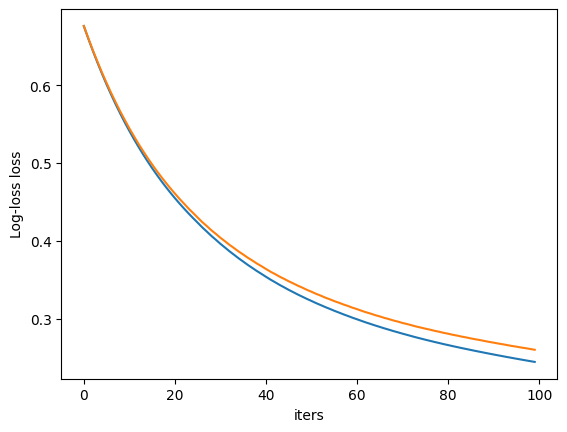

In [34]:
boosting = TrivialBoostingClassifier(n_iters=100, max_depth=2, learning_rate=0.1)
train_losses, val_losses = boosting.fit(X_train, y_train, X_val, y_val)
plt.plot(train_losses)
plt.plot(val_losses)
plt.xlabel('iters')
plt.ylabel('Log-loss loss')
print(f'Final validation loss is {val_losses[-1]}')

Final validation loss is 0.2598541019176939


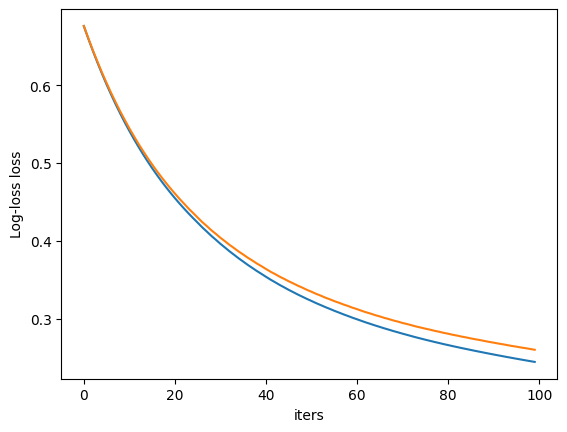

In [35]:
boosting = TrivialBoostingClassifier(n_iters=100, max_depth=2, learning_rate=0.1)
train_losses, val_losses = boosting.fit(X_train, y_train, X_val, y_val)
plt.plot(train_losses)
plt.plot(val_losses)
plt.xlabel('iters')
plt.ylabel('Log-loss loss')
print(f'Final validation loss is {val_losses[-1]}')

## Сравнение с эталоном

In [36]:
from sklearn.ensemble import GradientBoostingClassifier

In [37]:
def get_losses(sklearn_boost, X, y):
    losses = []
    for pred in sklearn_boost.staged_predict_proba(X):
        losses.append(log_loss(y, pred))
    return losses

Final validation loss is 0.05822590158588335


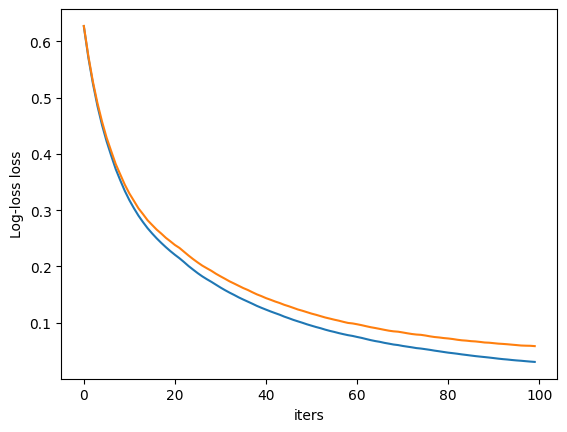

In [38]:
boosting = GradientBoostingClassifier(n_estimators=100,
                                      max_depth=2,
                                      learning_rate=0.1,
                                      criterion='squared_error')
boosting.fit(X_train, y_train)
train_losses = get_losses(boosting, X_train, y_train)
val_losses = get_losses(boosting, X_val, y_val)
plt.plot(train_losses)
plt.plot(val_losses)
plt.xlabel('iters')
plt.ylabel('Log-loss loss')
print(f'Final validation loss is {val_losses[-1]}')

В данной ситуации наша версия работает сильно хуже, чем sklearn.

Дело в том, что в этом случае мы как раз не можем пренебречь тем, что коэффициент b для каждого листа будет отличаться от того, что мы получаем обучением на антиградиентах.

Коэффициент придется вывести.

Вывод того, как считать коэффициент можно найти в [этой статье](https://arxiv.org/abs/2410.05623)

Вам достаточно найти нужную формулу

## Реализация корректного градиентного бустинга для задачи бинарной классификации

In [39]:
from sklearn.metrics import log_loss
from scipy.special import expit as sigmoid
class TrivialClassifierPredictor:
    def __init__(self, p):
        self.value = np.log(p / (1-p))

    def predict(self, X):
        return np.full(( X.shape[0], ), fill_value=self.value)

class CorrectedBoostingClassifier:
    def __init__(self, n_iters=100, max_depth=3, learning_rate=0.1):
        self.trivial_predictor = None
        self.ensemble = None
        self.n_iters = n_iters
        self.max_depth = max_depth
        self.learning_rate = learning_rate

    def predict(self, X):
        y_pred = self.trivial_predictor.predict(X)
        for base_model in self.ensemble:
            y_pred += self.learning_rate * base_model.predict(X)
        return sigmoid(y_pred)

    def update_leaves(self, tree, X, y_real, y_proba):
        leaves_ids = tree.apply(X)

        for leaf in np.unique(leaves_ids):
            leaf_objects = leaves_ids == leaf
            y_leaf_proba = y_proba[leaf_objects]
            y_leaf_real =  y_real[leaf_objects]
            numerator = (y_leaf_real - y_leaf_proba).sum()
            denominator = (y_leaf_proba * (1 - y_leaf_proba)).sum()
            if abs(denominator) < 1e-150:
                val = 0
            else:
                val = numerator / denominator
            tree.tree_.value[leaf, 0, 0] = val

    def fit(self, X, y, X_val=None, y_val=None):
        self.ensemble = []
        self.trivial_predictor = TrivialClassifierPredictor(p=y.mean())
        train_losses = []
        val_losses = []
        for _ in range(self.n_iters):
            y_pred = self.predict(X)
            train_losses.append(log_loss(y, y_pred))
            if X_val is not None and y_val is not None:
                y_val_pred = self.predict(X_val)
                val_losses.append(log_loss(y_val, y_val_pred))
            antigrad = y - y_pred
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X=X, y=antigrad)

            self.update_leaves(tree, X, y, y_pred)

            self.ensemble.append(tree)
        y_pred = self.predict(X)
        train_losses.append(log_loss(y, y_pred))
        if X_val is not None and y_val is not None:
            y_val_pred = self.predict(X_val)
            val_losses.append(log_loss(y_val, y_val_pred))
        return train_losses[1:], val_losses[1:] # remove trivial prediction



Final validation loss is 0.05822590158588336


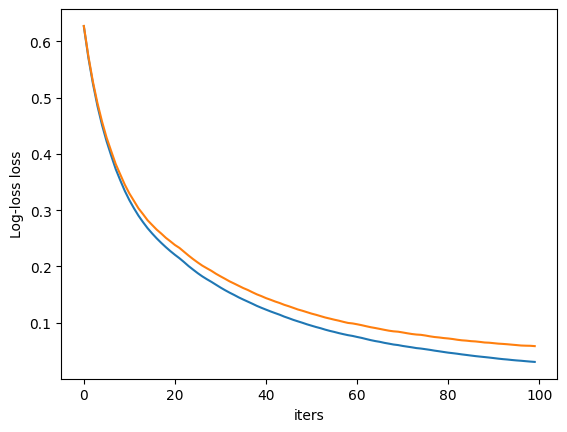

In [40]:
boosting = CorrectedBoostingClassifier(n_iters=100, max_depth=2, learning_rate=0.1)
train_losses, val_losses = boosting.fit(X_train, y_train, X_val, y_val)
plt.plot(train_losses)
plt.plot(val_losses)
plt.xlabel('iters')
plt.ylabel('Log-loss loss')
print(f'Final validation loss is {val_losses[-1]}')

# **** Задание 5. SemiBoost (1 балл)

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import xgboost as xgb
from matplotlib.colors import ListedColormap

X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = X.astype(np.float32)
y = y.astype(np.float32)

In [42]:
def plot_decision_boundary(X, y, model, title):
    # Define mesh grid
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00'])

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(title)
    plt.show()

## Обучаем xgboost используя scikit-learn интерфейс

In [43]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

In [44]:
model = xgb.XGBClassifier(
    n_estimators=100,
    early_stopping_rounds=10,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)])

train_accuracy = model.score(X_train, y_train)
val_accuracy = model.score(X_val, y_val)
print(f"Training accuracy: {train_accuracy:.2f}")
print(f"Validation accuracy: {val_accuracy:.2f}")

[0]	validation_0-logloss:0.62718	validation_1-logloss:0.62559
[1]	validation_0-logloss:0.57305	validation_1-logloss:0.56912
[2]	validation_0-logloss:0.52786	validation_1-logloss:0.52179
[3]	validation_0-logloss:0.48975	validation_1-logloss:0.48164
[4]	validation_0-logloss:0.45471	validation_1-logloss:0.44638
[5]	validation_0-logloss:0.42649	validation_1-logloss:0.41643
[6]	validation_0-logloss:0.40216	validation_1-logloss:0.39072
[7]	validation_0-logloss:0.37842	validation_1-logloss:0.36710
[8]	validation_0-logloss:0.35713	validation_1-logloss:0.34719
[9]	validation_0-logloss:0.33881	validation_1-logloss:0.33008
[10]	validation_0-logloss:0.32088	validation_1-logloss:0.31221
[11]	validation_0-logloss:0.30337	validation_1-logloss:0.29472
[12]	validation_0-logloss:0.28846	validation_1-logloss:0.28103
[13]	validation_0-logloss:0.27372	validation_1-logloss:0.26664
[14]	validation_0-logloss:0.26124	validation_1-logloss:0.25545
[15]	validation_0-logloss:0.24852	validation_1-logloss:0.24326
[1

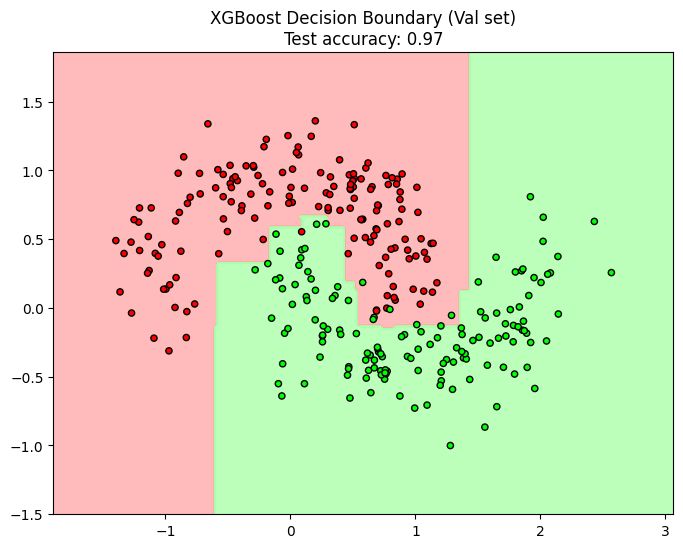

In [45]:
plot_decision_boundary(X_val, y_val, model,
                      "XGBoost Decision Boundary (Val set)\n"
                      f"Test accuracy: {val_accuracy:.2f}")

## Обучаем xgboost используя встроенный интерфейс

In [46]:
X_train_labeled = X_train.copy()
y_train_labeled = y_train.copy()

params={'eta':0.1,
       'disable_default_eval_metric': 1,
        'eval_metric':'logloss',
        'objective': 'binary:logistic',
        'seed': 42,
        'max_depth': 3}

dmat_train=xgb.DMatrix(X_train_labeled,y_train_labeled)
dmat_val=xgb.DMatrix(X_val,y_val)

model=xgb.train(params,
                dmat_train,
                num_boost_round=100,
                early_stopping_rounds=10,
                evals=[(dmat_train,'train'),(dmat_val,'validation')])

[0]	train-logloss:0.62718	validation-logloss:0.62559
[1]	train-logloss:0.57305	validation-logloss:0.56912
[2]	train-logloss:0.52786	validation-logloss:0.52179
[3]	train-logloss:0.48975	validation-logloss:0.48164
[4]	train-logloss:0.45471	validation-logloss:0.44638
[5]	train-logloss:0.42649	validation-logloss:0.41643
[6]	train-logloss:0.40216	validation-logloss:0.39072
[7]	train-logloss:0.37842	validation-logloss:0.36710
[8]	train-logloss:0.35713	validation-logloss:0.34719
[9]	train-logloss:0.33881	validation-logloss:0.33008
[10]	train-logloss:0.32088	validation-logloss:0.31221
[11]	train-logloss:0.30337	validation-logloss:0.29472
[12]	train-logloss:0.28846	validation-logloss:0.28103
[13]	train-logloss:0.27372	validation-logloss:0.26664
[14]	train-logloss:0.26124	validation-logloss:0.25545
[15]	train-logloss:0.24852	validation-logloss:0.24326
[16]	train-logloss:0.23747	validation-logloss:0.23307
[17]	train-logloss:0.22643	validation-logloss:0.22264
[18]	train-logloss:0.21630	validation-

In [47]:
y_train_pred = model.predict(dmat_train) > 0.5
train_accuracy = (y_train_pred == y_train).mean()
y_val_pred = model.predict(dmat_val) > 0.5
val_accuracy = (y_val_pred == y_val).mean()
print(f"Training accuracy: {train_accuracy:.2f}")
print(f"Validation accuracy: {val_accuracy:.2f}")

Training accuracy: 0.99
Validation accuracy: 0.97


In [48]:
def plot_decision_boundary_xgb(X, y, model, title):
    # Define mesh grid
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Xgrid = np.stack([xx.ravel(), yy.ravel()], axis=1)
    dmat = xgb.DMatrix(Xgrid)

    Z = model.predict(dmat) > 0.5
    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00'])

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(title)
    plt.show()

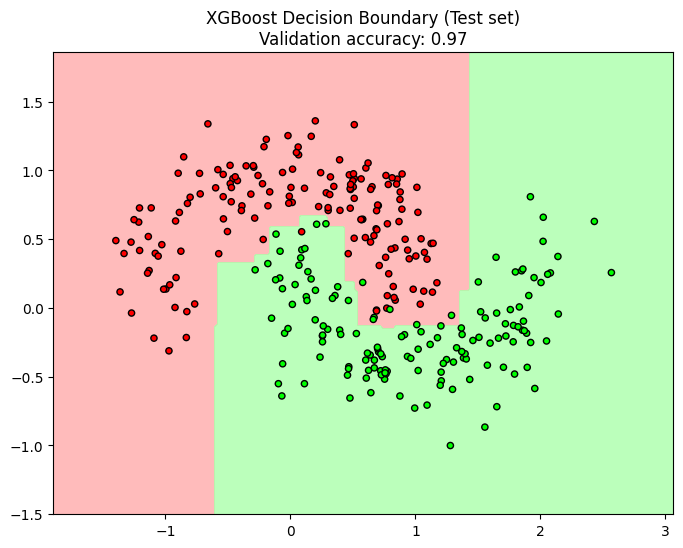

In [49]:
plot_decision_boundary_xgb(X_val,
                       y_val,
                       model,
                      "XGBoost Decision Boundary (Test set)\n"
                      f"Validation accuracy: {val_accuracy:.2f}")

## Переписываем таким образом, чтобы xgboost работал с нашей функцией подсчета градентов и гессиана

Xgboost для наших функций ошибки НЕ знает, как преобразовывать сырые предсказания градиентного бустинга

Потому преобразование придется делать самим

In [50]:
from scipy.special import expit as sigmoid

In [51]:
def custom_logloss_metric(preds, dtrain):
    """
    Custom log loss evaluation metric for XGBoost.

    Parameters:
    preds -- predicted probabilities (before logistic transformation)
    dtrain -- DMatrix object containing training data

    Returns:
    name -- metric name
    value -- metric value
    """
    y_true = dtrain.get_label()
    y_pred = sigmoid(preds)

    # Calculate log loss
    logloss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    return 'custom_logloss', logloss

def custom_logloss_objective(preds, dtrain):
    """
    Custom logistic loss objective function for XGBoost.

    Parameters:
    preds -- predicted probabilities (before logistic transformation)
    dtrain -- DMatrix object containing training data

    Returns:
    grad -- gradient of the loss
    hess -- hessian (second derivative) of the loss
    """
    # Extract true labels
    y_true = dtrain.get_label()

    # Apply sigmoid to get probabilities (since preds are log-odds)
    y_pred = sigmoid(preds)

    # Compute gradient and hessian
    grad = y_pred - y_true

    hess = y_pred * (1 - y_pred)


    return grad, hess


In [52]:
def plot_decision_boundary_xgb(X, y, model, title):
    # Define mesh grid
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Xgrid = np.stack([xx.ravel(), yy.ravel()], axis=1)
    dmat = xgb.DMatrix(Xgrid)

    Z = sigmoid(model.predict(dmat)) > 0.5
    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00'])

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(title)
    plt.show()

In [53]:
X_train_labeled = X_train.copy()
y_train_labeled = y_train.copy()

params={'eta':0.1,
        'disable_default_eval_metric': 1,
        'seed': 42,
        'max_depth': 3}

dmat_train=xgb.DMatrix(X_train_labeled,y_train_labeled)
dmat_val=xgb.DMatrix(X_val,y_val)

model=xgb.train(params,
                dmat_train,
                num_boost_round=100,
                early_stopping_rounds=10,
                obj=custom_logloss_objective,
                custom_metric=custom_logloss_metric,
                evals=[(dmat_train,'train'),(dmat_val,'validation')])

[0]	train-custom_logloss:0.64502	validation-custom_logloss:0.65373
[1]	train-custom_logloss:0.58341	validation-custom_logloss:0.58998
[2]	train-custom_logloss:0.53305	validation-custom_logloss:0.53804
[3]	train-custom_logloss:0.49213	validation-custom_logloss:0.49378
[4]	train-custom_logloss:0.45608	validation-custom_logloss:0.45625
[5]	train-custom_logloss:0.42640	validation-custom_logloss:0.42419
[6]	train-custom_logloss:0.40099	validation-custom_logloss:0.39629
[7]	train-custom_logloss:0.37911	validation-custom_logloss:0.37282
[8]	train-custom_logloss:0.35703	validation-custom_logloss:0.34973
[9]	train-custom_logloss:0.33871	validation-custom_logloss:0.33109
[10]	train-custom_logloss:0.32003	validation-custom_logloss:0.31397
[11]	train-custom_logloss:0.30319	validation-custom_logloss:0.29654
[12]	train-custom_logloss:0.28750	validation-custom_logloss:0.28225
[13]	train-custom_logloss:0.27331	validation-custom_logloss:0.26817
[14]	train-custom_logloss:0.25952	validation-custom_loglos

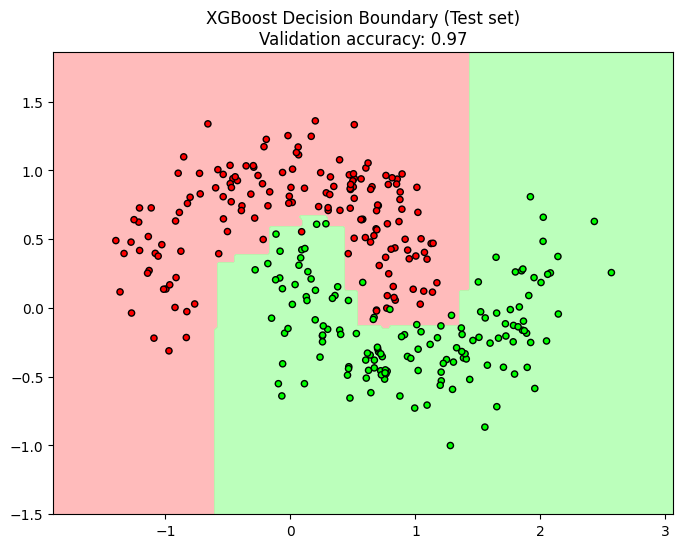

In [54]:
plot_decision_boundary_xgb(X_val,
                       y_val,
                       model,
                      "XGBoost Decision Boundary (Test set)\n"
                      f"Validation accuracy: {val_accuracy:.2f}")

## Обучение только на части обучающей выборки

Допустим, что мы знаем метки только для 2% наших точек из обучающей выборки. Как тогда справится наша модель?

In [55]:
np.random.seed(888)
known_train = np.random.choice([False, True], size=X_train.shape[0], p=[0.98, 0.02])

X_train_labeled = X_train.copy()
X_train_labeled = X_train_labeled[known_train]
y_train_labeled = y_train.copy()
y_train_labeled = y_train_labeled[known_train]

params={'eta':0.1,
        'disable_default_eval_metric': 1,
        'seed': 42,
        'max_depth': 3}

dmat_train=xgb.DMatrix(X_train_labeled,y_train_labeled)
dmat_val=xgb.DMatrix(X_val,y_val)

model = xgb.train(params,
                  dmat_train,
                  obj=custom_logloss_objective,
                  custom_metric=custom_logloss_metric,
                  num_boost_round=100,
                  early_stopping_rounds=10,
                  evals=[(dmat_train,'train'),(dmat_val,'validation')],
                  )

[0]	train-custom_logloss:0.65230	validation-custom_logloss:0.70615
[1]	train-custom_logloss:0.62070	validation-custom_logloss:0.68241
[2]	train-custom_logloss:0.59290	validation-custom_logloss:0.66219
[3]	train-custom_logloss:0.56836	validation-custom_logloss:0.64494
[4]	train-custom_logloss:0.54664	validation-custom_logloss:0.63021
[5]	train-custom_logloss:0.52735	validation-custom_logloss:0.61763
[6]	train-custom_logloss:0.50979	validation-custom_logloss:0.59708
[7]	train-custom_logloss:0.49398	validation-custom_logloss:0.58697
[8]	train-custom_logloss:0.47961	validation-custom_logloss:0.56950
[9]	train-custom_logloss:0.46654	validation-custom_logloss:0.56131
[10]	train-custom_logloss:0.45471	validation-custom_logloss:0.54633
[11]	train-custom_logloss:0.44384	validation-custom_logloss:0.53964
[12]	train-custom_logloss:0.43404	validation-custom_logloss:0.52670
[13]	train-custom_logloss:0.42529	validation-custom_logloss:0.51501
[14]	train-custom_logloss:0.41745	validation-custom_loglos

In [56]:
y_train_pred = model.predict(dmat_train) > 0
train_accuracy = (y_train_pred == y_train_labeled).mean()
y_val_pred = model.predict(dmat_val) > 0

val_accuracy = (y_val_pred == y_val).mean()
print(f"Training accuracy: {train_accuracy:.2f}")
print(f"Validation accuracy: {val_accuracy:.2f}")

Training accuracy: 0.86
Validation accuracy: 0.85


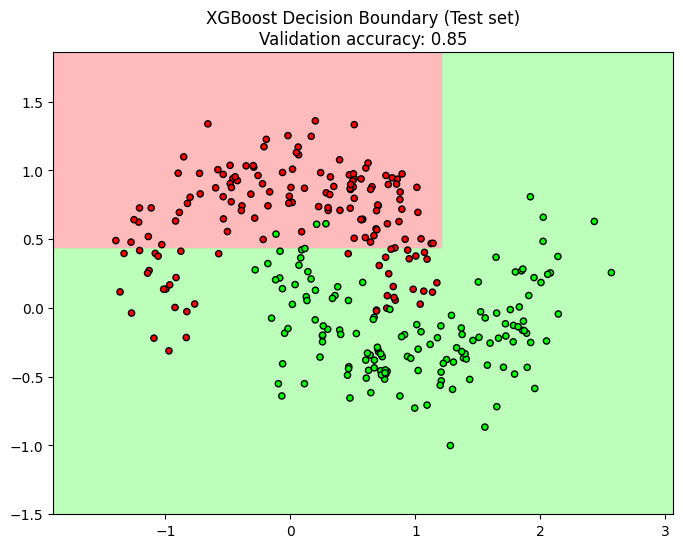

In [57]:
plot_decision_boundary_xgb(X_val,
                       y_val,
                       model,
                      "XGBoost Decision Boundary (Test set)\n"
                      f"Validation accuracy: {val_accuracy:.2f}")

## Кластеризация

Но на самом деле нам известны признаки других объектов из обучающего набора -- и мы можем посмотреть, какие из них похожи на размеченные

In [58]:
from sklearn.cluster import AffinityPropagation, KMeans
cluster = KMeans(n_clusters=8, random_state=42)
cluster.fit(X_train) # можем ли мы учить кластеризацию на всех данных?
cluster_ids = cluster.predict(X_train)

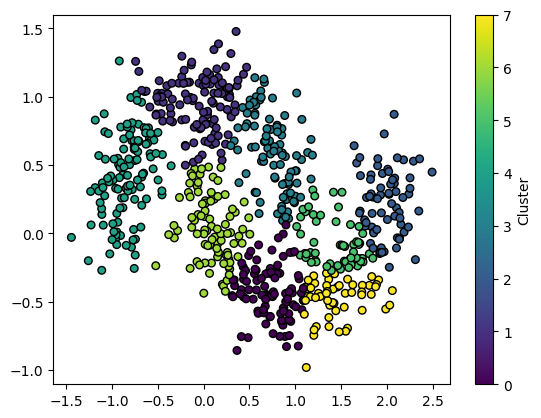

In [59]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=cluster_ids, s=30, edgecolor='k')
plt.colorbar(label='Cluster')
plt.show()

## Semi-supervised подход

Теперь же мы добавим наш лосс следующее требование - мы хотим, чтобы для объектов в одной кластере предсказанные значения отличались не сильно. Самый простой способ -- просто считать дисперсию предсказаний каждого кластера


In [60]:
ALPHA = 1.0

def custom_logloss_metric(preds, dtrain):
    """
    Custom log loss evaluation metric for XGBoost.

    Parameters:
    preds -- predicted probabilities (before logistic transformation)
    dtrain -- DMatrix object containing training data

    Returns:
    name -- metric name
    value -- metric value
    """
    y_true = dtrain.get_label()
    y_pred = 1.0 / (1.0 + np.exp(-preds))

    # Clip predictions to avoid log(0)
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    y_known = y_true != -1

    cluster_ids = cluster.predict(dtrain.get_data())

    loss= 0
    for clust_id in np.unique(cluster_ids):
        clust_mask = cluster_ids == clust_id
        N = clust_mask.sum()
        y_pred_clust = y_pred[clust_mask]
        loss += y_pred_clust.var()

    y_true = y_true[y_known]
    y_pred = y_pred[y_known]
    # Calculate log loss
    logloss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    return 'custom_logloss_part', logloss + loss * ALPHA

def custom_logloss_objective_partial(preds, dtrain):
    """
    Custom logistic loss objective function for XGBoost.

    Parameters:
    preds -- predicted probabilities (before logistic transformation)
    dtrain -- DMatrix object containing training data

    Returns:
    grad -- gradient of the loss
    hess -- hessian (second derivative) of the loss
    """
    # Extract true labels
    y_true = dtrain.get_label()
    y_known = y_true != -1

    # Apply sigmoid to get probabilities (since preds are log-odds)
    y_pred = 1.0 / (1.0 + np.exp(-preds))
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)

    # Compute gradient and hessian
    grad = np.zeros_like(y_pred)
    hess = np.zeros_like(y_pred)

    cluster_ids = cluster.predict(dtrain.get_data())

    for clust_id in np.unique(cluster_ids):
        clust_mask = cluster_ids == clust_id
        N = clust_mask.sum()
        y_pred_clust = y_pred[clust_mask]
        y_mean = y_pred_clust.mean()
        grad[clust_mask] = 2 * (y_pred_clust - y_mean) / N
        hess[clust_mask] = 2 * (1 - 1/N) / N

    grad[y_known] += y_pred[y_known] - y_true[y_known]
    hess[y_known] += y_pred[y_known] * (1 - y_pred[y_known])

    return grad, hess

In [61]:
X_train, X_val, y_train, y_val = train_test_split(X,
                                                  y,
                                                  test_size=0.3,
                                                  random_state=42)
X_train_labeled = X_train.copy()
y_train_labeled = y_train.copy()
y_train_labeled[~known_train] = -1

params={'eta':0.1,
        'disable_default_eval_metric': 1,
        'seed': 42}

dmat_train=xgb.DMatrix(X_train_labeled,y_train_labeled)
dmat_val=xgb.DMatrix(X_val,y_val)

model=xgb.train(params,
                  dmat_train,
                num_boost_round=1000,
                early_stopping_rounds=10,
                 obj=custom_logloss_objective_partial,
                  evals=[(dmat_train,'train'),(dmat_val,'validation')],
                custom_metric=custom_logloss_metric)


[0]	train-custom_logloss_part:0.66439	validation-custom_logloss_part:0.72517
[1]	train-custom_logloss_part:0.64203	validation-custom_logloss_part:0.71708
[2]	train-custom_logloss_part:0.62118	validation-custom_logloss_part:0.70975
[3]	train-custom_logloss_part:0.60173	validation-custom_logloss_part:0.70312
[4]	train-custom_logloss_part:0.58360	validation-custom_logloss_part:0.69713
[5]	train-custom_logloss_part:0.56668	validation-custom_logloss_part:0.69175
[6]	train-custom_logloss_part:0.55091	validation-custom_logloss_part:0.68691
[7]	train-custom_logloss_part:0.53619	validation-custom_logloss_part:0.68257
[8]	train-custom_logloss_part:0.52246	validation-custom_logloss_part:0.67869
[9]	train-custom_logloss_part:0.50963	validation-custom_logloss_part:0.67524
[10]	train-custom_logloss_part:0.49766	validation-custom_logloss_part:0.67217
[11]	train-custom_logloss_part:0.48549	validation-custom_logloss_part:0.66900
[12]	train-custom_logloss_part:0.47406	validation-custom_logloss_part:0.66

In [62]:
y_train_pred = model.predict(dmat_train) > 0
train_accuracy = (y_train_pred[known_train] == y_train_labeled[known_train]).mean()
y_val_pred = model.predict(dmat_val) > 0

val_accuracy = (y_val_pred == y_val).mean()
print(f"Training accuracy: {train_accuracy:.2f}")
print(f"Validation accuracy: {val_accuracy:.2f}")

Training accuracy: 1.00
Validation accuracy: 0.79


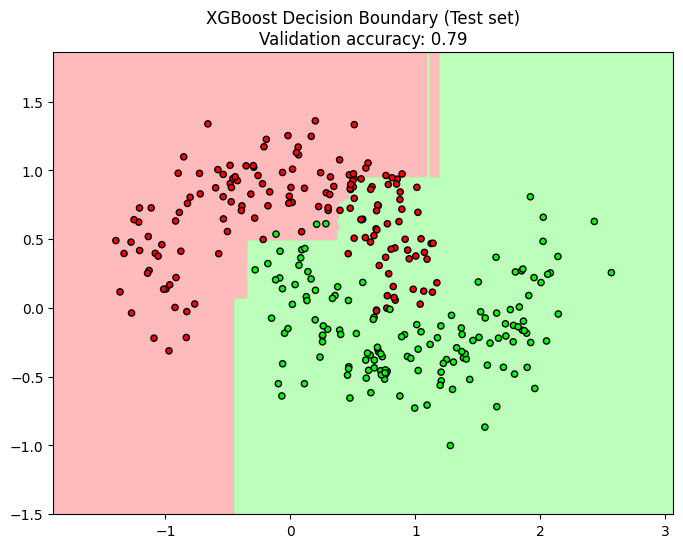

In [63]:
plot_decision_boundary_xgb(X_val,
                       y_val,
                       model,
                      "XGBoost Decision Boundary (Test set)\n"
                      f"Validation accuracy: {val_accuracy:.2f}")

# Задача 7 (1 балл): Обучение на геномных эмбеддингах

В этой задаче предлагается произвести предсказание изменения экспрессии гена в зависимости от разных однонуклеотидных замен в регуляторном участке ДНК, основываясь на нейросетевых геномных эмбеддингах этого участка.

In [114]:
!wget https://data.bioml.ru/htdocs/courses/bioml/classic_ml/supervised/knn/data/tfs_deepsea.csv

--2026-05-13 19:59:37--  https://data.bioml.ru/htdocs/courses/bioml/classic_ml/supervised/knn/data/tfs_deepsea.csv
Resolving data.bioml.ru (data.bioml.ru)... 188.120.231.217
Connecting to data.bioml.ru (data.bioml.ru)|188.120.231.217|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1098058 (1.0M) [text/csv]
Saving to: ‘tfs_deepsea.csv.2’

tfs_deepsea.csv.2   100%[===================>]   1.05M  5.08MB/s    in 0.2s    

2026-05-13 19:59:37 (5.08 MB/s) - ‘tfs_deepsea.csv.2’ saved [1098058/1098058]



Загрузите датасет `tfs_deepsea.csv`, в качестве `y` используйте колонку `Direction`, в качестве `X` - все колонки, начиная с девятой.

In [115]:
df = pd.read_csv('tfs_deepsea.csv')
df

,Chrom,Pos,Ref,Alt,Value,Confidence,Direction,construction,alt@BRCA1@ds_HepG2_normal,alt@CTCF@ds_HCM_normal,...,ref@GATA3@ds_MCF-7_normal,ref@JunD@ds_H1-hESC_None.1,ref@MafK@ds_K562_normal,ref@NRSF@ds_A549_EtOH_0.02pct,ref@Pol2-4H8@ds_GM12891_normal,ref@Pol2@ds_GM12878_None.2,ref@Pol2@ds_GM12878_None.3,ref@Pol2@ds_GM12878_normal,ref@c-Fos@ds_K562_normal,ref@c-Myc@ds_K562_normal
0,9,104195582,G,C,-0.009418,0.001075,0,ALDOB,0.000056,0.000949,...,0.009340,0.000637,0.082889,0.007880,0.000568,0.000095,0.000287,0.000147,0.000588,0.001214
1,9,104195582,G,T,-0.212088,0.034187,0,ALDOB,0.000051,0.000857,...,0.009340,0.000637,0.082889,0.007880,0.000568,0.000095,0.000287,0.000147,0.000588,0.001214
2,9,104195700,T,A,0.709840,0.364072,1,ALDOB,0.000089,0.001784,...,0.002920,0.001019,0.100890,0.004289,0.000554,0.000142,0.000209,0.000282,0.001091,0.000891
3,9,104195700,T,C,-0.449200,0.068867,0,ALDOB,0.000091,0.001538,...,0.002920,0.001019,0.100890,0.004289,0.000554,0.000142,0.000209,0.000282,0.001091,0.000891
4,9,104195700,T,G,0.090531,0.008654,0,ALDOB,0.000103,0.001784,...,0.002920,0.001019,0.100890,0.004289,0.000554,0.000142,0.000209,0.000282,0.001091,0.000891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2,169939631,A,G,-0.738824,0.273784,-1,ECR11,0.000107,0.000450,...,0.000566,0.000237,0.001906,0.001458,0.013105,0.012392,0.018892,0.005048,0.000253,0.011511
996,2,169939631,A,T,-0.870909,0.356729,-1,ECR11,0.000095,0.000407,...,0.000566,0.000237,0.001906,0.001458,0.013105,0.012392,0.018892,0.005048,0.000253,0.011511
997,2,169939136,T,A,-0.020664,0.002457,0,ECR11,0.000027,0.000490,...,0.005459,0.000162,0.001430,0.002021,0.000563,0.000065,0.000303,0.000116,0.000067,0.000452
998,2,169939136,T,C,0.026841,0.003130,0,ECR11,0.000028,0.000499,...,0.005459,0.000162,0.001430,0.002021,0.000563,0.000065,0.000303,0.000116,0.000067,0.000452


In [116]:
y = df['Direction'].values
X = df.iloc[:, 8:].values

**Разбейте X и y на тренировочную и тестовую выборки**, как в лекции. Соотношение train/test поставьте равным 4:1.\
*Подсказка*: воспользуйтесь функцией `train_test_split`.

In [117]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [118]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [119]:
b = np.unique(y_test)
b

array([-1,  0,  1])

**Обучите модели случайного леса и градиентного бустинга  на соответствующей части выборки (`model.fit`)**.

In [120]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

In [121]:
y_pred_rf = rf.predict(X_test)
y_pred_rf

array([-1.15887072e-03,  4.75435820e-03, -1.15887072e-03, -1.47617230e-02,
       -1.83763169e-03, -1.83763169e-03, -1.15887072e-03, -1.15887072e-03,
       -1.83763169e-03, -5.67740934e-02,  4.63988191e-02, -4.35914955e-01,
       -1.15887072e-03, -3.47906360e-01,  2.85591931e-01, -1.76607534e-03,
       -9.69393367e-04, -1.83763169e-03, -1.15887072e-03, -1.02549853e-02,
       -1.15887072e-03, -2.84042257e-03,  1.67541989e-02, -1.15887072e-03,
        1.16995672e-01,  8.24032117e-02, -4.76047958e-01,  6.44728446e-01,
        4.18636927e-03, -5.53595588e-01, -1.29075334e-02, -2.21258493e-01,
       -1.94104218e-03, -1.90893294e-03, -3.74502453e-03, -8.36604218e-03,
        8.85774057e-03, -1.83763169e-03, -9.16028254e-02, -6.52500000e-01,
       -1.15887072e-03, -9.10000000e-01, -3.77878154e-03,  5.54655465e-02,
       -1.13258673e-02, -1.31509069e-02, -2.53557514e-01, -1.15887072e-03,
       -9.69393367e-04, -1.67582758e-02, -1.15887072e-03, -1.10005480e-02,
       -9.32603786e-02, -

In [122]:
gb = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=5, random_state=42)

In [123]:
y_pred_gb = gb.predict(X_test)
y_pred_gb

array([ 7.89017443e-03,  9.91673728e-03, -3.41765487e-03, -1.83051337e-01,
       -2.70572618e-03, -1.01658075e-02,  5.31516224e-03,  4.38929884e-03,
       -1.43289943e-02, -1.93600499e-01, -2.84924870e-02, -2.75238334e-01,
        7.56909378e-03, -2.31526009e-01,  1.81581406e-01, -1.00621999e-02,
        4.23478160e-02, -2.33369552e-03, -3.72760791e-03,  2.15077790e-02,
        5.32144551e-03,  1.67307318e-02,  3.31152667e-01,  6.96077940e-03,
        2.16782161e-01,  1.31739766e-01, -6.07298327e-01,  6.21276891e-01,
       -8.64771198e-03, -6.10894089e-01, -2.45977210e-03, -2.74220839e-01,
       -6.40828436e-03, -2.10292672e-02,  2.94595094e-03,  1.26483989e-02,
        5.91150917e-03, -1.00083041e-02, -1.49358139e-01, -8.66350712e-01,
        2.72959016e-03, -1.04008354e+00,  3.38830671e-02, -3.93273508e-03,
        1.13317069e-02, -3.25522939e-02, -2.99101746e-01,  5.96973524e-03,
        4.01058681e-02, -5.30680010e-03,  6.84407628e-03, -6.85153420e-02,
       -1.06913553e-02,  

**Получите предсказание на оставшейся выборке**. Оцените его качество метриками MSE и RMSE. Насколько хороша модель?

In [124]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

In [125]:
mse_rf

0.08365167921479232

In [126]:
rmse_rf

np.float64(0.2892260002399375)

In [127]:
r2_rf

0.3848010353756769

In [128]:
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

In [129]:
mse_gb

0.08022555936599086

In [130]:
rmse_gb

np.float64(0.2832411682047489)

In [131]:
r2_gb

0.4099977248318376

Оцените качество графически и с помощью коэффициента корреляции Пирсона.

In [132]:
from scipy.stats import pearsonr
corr_rf, p_rf = pearsonr(y_test, y_pred_rf)
corr_gb, p_gb = pearsonr(y_test, y_pred_gb)

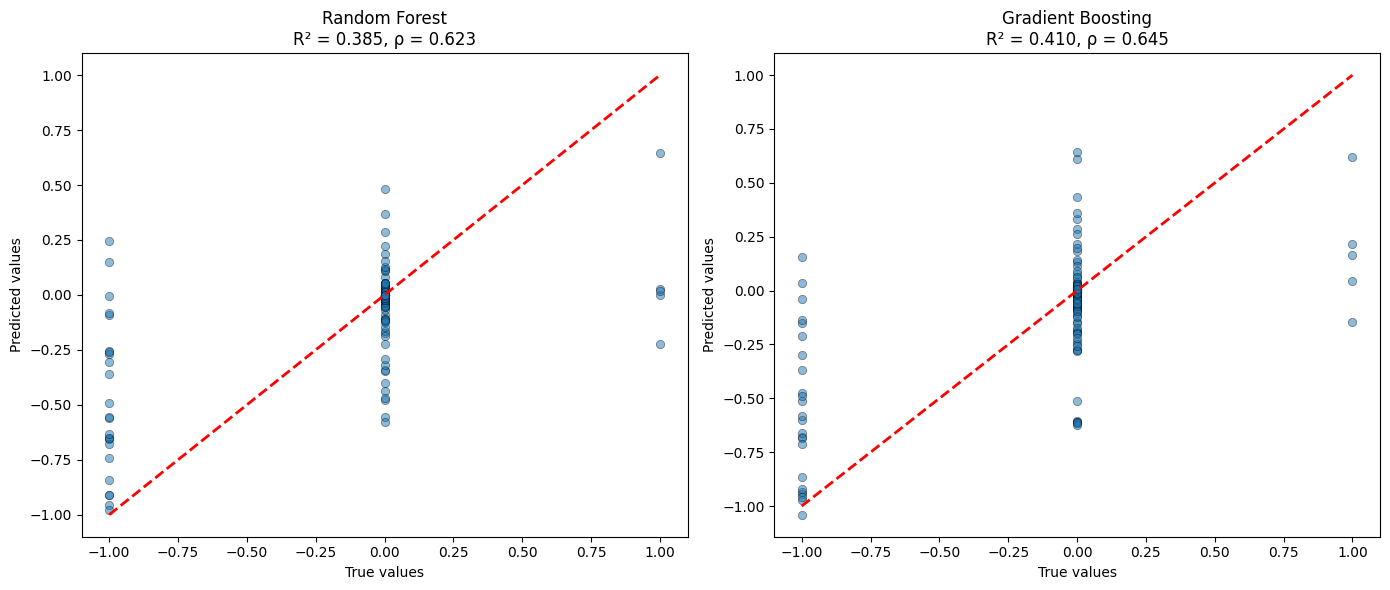

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
#random forest
axes[0].scatter(y_test, y_pred_rf, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('True values')
axes[0].set_ylabel('Predicted values')
axes[0].set_title(f'Random Forest\nR² = {r2_rf:.3f}, ρ = {corr_rf:.3f}')

#gradient boosting
axes[1].scatter(y_test, y_pred_gb, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('True values')
axes[1].set_ylabel('Predicted values')
axes[1].set_title(f'Gradient Boosting\nR² = {r2_gb:.3f}, ρ = {corr_gb:.3f}')

plt.tight_layout()
plt.show()

Разбейте X и y на тренировочную и тестовую выборки, **так, как указано в ячейке ниже**. Повторите все шаги, чтобы определить качество регрессии случайного леса и градиентного бустинга

Биологический смысл указанного разбиения: использовать для обучения один промоторный регион при осуществлении предсказания на другом.

In [134]:
y = df['Direction'].values
X = df.iloc[:, 8:].values

In [135]:
X_train = X[df["construction"] == "ECR11"]
X_test = X[df["construction"] == "ALDOB"]
y_train = y[df["construction"] == "ECR11"]
y_test = y[df["construction"] == "ALDOB"]


In [136]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [137]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)
corr_rf, p_rf = pearsonr(y_test, y_pred_rf)

In [138]:
mse_rf

0.2773436270587035

In [139]:
rmse_rf

np.float64(0.5266342440999289)

In [140]:
r2_rf

-0.28162489398661505

In [141]:
corr_rf, p_rf

(np.float64(0.07777121706403256), np.float64(0.08233480188016896))

In [142]:
gb = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

In [143]:
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)
corr_gb, p_gb = pearsonr(y_test, y_pred_gb)

In [144]:
mse_gb

0.4031973284357046

In [145]:
rmse_gb

np.float64(0.6349782109928691)

In [146]:
r2_gb

-0.8632039206825532

In [147]:
corr_gb, p_gb

(np.float64(0.09578722004867053), np.float64(0.0322391713122844))

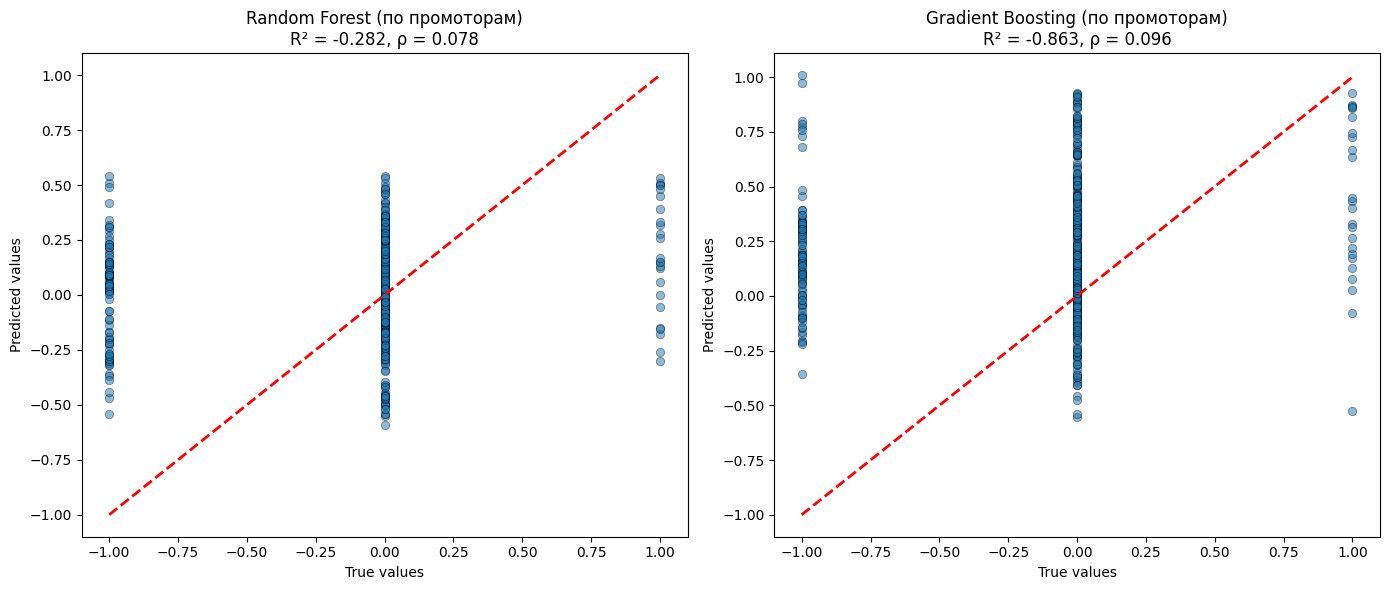

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#random forest
axes[0].scatter(y_test, y_pred_rf, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('True values')
axes[0].set_ylabel('Predicted values')
axes[0].set_title(f'Random Forest (по промоторам)\nR² = {r2_rf:.3f}, ρ = {corr_rf:.3f}')

#gradient boosting
axes[1].scatter(y_test, y_pred_gb, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('True values')
axes[1].set_ylabel('Predicted values')
axes[1].set_title(f'Gradient Boosting (по промоторам)\nR² = {r2_gb:.3f}, ρ = {corr_gb:.3f}')

plt.tight_layout()
plt.show()

Объясните наблюдаемое различие?

Какому качеству стоит верить -- на случайном разбиении или на разбиении по промоторным регионам?

Считаете ли вы, что в данном случае имеет место утечка данных? Мнение обоснуйте

* При случайном разбиении random
forest mse=0.0865, rmse = 0.2892, r^2=0.3848
* При случайном разбиении gradient boosting mse=0.0802, rmse = 0.2832, r^2=0.4099
* При случайном разбиении random forest mse=0.0865, rmse = 0.2892, r^2=0.3848
* При разбиении по промоторам gradient boosting mse=0.4031, rmse = 0.6349, r^2=-0.8632

Таким образом, при случайном разбиении модели показывают хорошее качество. Однако при разбиении по промоторным регионам (обучение на ECR11, тестирование на ALDOB) качество градиентного бустинга резко падает, так как mse возрастает до 0.4031, rmse до 0.6349, а r^2 становится отрицательным (-0.8632). Это означает, что модель предсказывает хуже, чем простое среднее значение, и плохо улавливает закономерности с одного промотора на другой.

Верить следует качеству, полученному при разбиении по промоторам, тк оно единственное биологически корректно проверяет способность модели к обобщению на геном. В данном случае есть утечка данных при случайном разбиении, то есть объекты из промотора ALDOB попадают в обучающую выборку, поэтому тестирование на них дпоказывает завышенные результаты. Но качество модели оказывается плохим (r^2< 0), это подчёркивает важность правильного разделения данных по биологически независимым группам.

---